In [1]:
#!/usr/bin/env python3

import numpy as np
import sys
import json 
from scipy.optimize import minimize, brentq
from matplotlib import pyplot as plt
import matplotlib as mpl
import mplhep as hep
hep.style.use("ATLAS")

sys.path.append('../Recast/CMS-TOP-20-001_mtt')

from cms_top_20_001_Limits import read_CMSdata, getSMLO, getKfactor, cms_bins, bin_widths, getUL

brFactor = 2*0.67*0.2147 # Semi-leptonic branching ratio to be applied to the ttbar (undecayed) signal

## Extract signal cross-sections from MG5 output:

In [2]:
def getBinsFrom(inputFile="../pp2ttbar-loop_smefit/Events/run_01/MADatNLO.HwU",
                hist_label="CMS_2021_mtt-",weightFactor=brFactor):
    
    with open(inputFile,'r') as f:
        data = f.read().split('<histogram>')[1:]

    histogram = []
    for hist in data:
        lines = hist.split('\n')
        if not (hist_label in lines[0]):
            continue
        low_edge,high_edge,bin_value = lines[1].split()[:3]
        histogram.append([float(low_edge),float(high_edge),float(bin_value)*weightFactor ])
    
    return np.array(histogram)

# Since the tops have not decayed and the CMS data refers to semi-leptonic ttbar, we must multiply by
# BR(W+ -> l+ nu)*BR(W- -> hadronic) + BR(W- -> l- nu)*BR(W+ -> hadronic) = 2*0.2*0.67
histogram = getBinsFrom("../pp2ttbar-loop_smefit/Events/run_01/MADatNLO.HwU","CMS_2021_mtt-",brFactor)



## Compute Limits on yDM

In [3]:
def computeULs(histogram,full=False,cl=0.95,covMatrix=None,kfac=None):

    # ### Load CMS data and BG
    xsecsObs,sm,covMatrix_cms = read_CMSdata(dataDir='../Recast/CMS-TOP-20-001_mtt/data')
    if covMatrix is None:
        covMatrix = covMatrix_cms
    
    # ### Load LO background from MG5
    smLO = getSMLO(smFile='../Recast/CMS-TOP-20-001_mtt/sm/sm_tt_lo_cms_top_20_001.pcl')
    # Get k-factor for each bin
    kfac_sm = getKfactor(sm,smLO)
    if kfac is None:
        kfac = kfac_sm

    
    bins_left = histogram[:,0]
    bins_right = histogram[:,1]
    bin_values = histogram[:,2]
    # Check that bins are consistent:
    if not np.array_equal(bins_left,cms_bins[:-1]):
        print('Bins from data do not match CMS')
        return
    if bins_right[-1] != cms_bins[-1]:
        print('Bins from data do not match CMS')
        return

    signal = list(zip(bins_left,bin_values))
    signal = np.array(sorted(signal))[:,1]
    yDM = 1.0
    # Make sure signal is normalized to yDM = 1
    signal = signal[:]/yDM**2
    # Rescale predictions by bin-dependent k-factors
    signal = kfac*signal[:]

    if not full: # Use simplified chi-square
        # Finally, divide by the bin widths
        signal = signal/bin_widths
        sm_bin = sm/bin_widths
        resDict = getUL(signal,sm_bin,xsecsObs,covMatrix,deltas=0.0,cl=cl)
        yDM95 = resDict[f'yDM{int(cl*100)}']
        deltaChi95 = resDict[f'deltaChi{int(cl*100)}']       

        # Expected
        resDictExp = getUL(signal,sm_bin,sm_bin,covMatrix,deltas=0.0,cl=cl)
        yDM95exp = resDictExp[f'yDM{int(cl*100)}']            
        
    else: # Use full CLs calculation
        import sys
        sys.path.append('../statisticalTools')
        from simplifiedLikelihoods import Data,UpperLimitComputer,LikelihoodComputer
        ulComp = UpperLimitComputer(cl=cl)

        # ### Get number of observed and expected (BG) events
        lumi = 137*1e3
        nobs = xsecsObs*bin_widths*lumi
        nbg = sm*lumi
        ns = signal*lumi
        cov = covMatrix*(lumi*bin_widths)**2
        data = Data(observed=nobs, backgrounds=nbg, 
                    covariance=cov, 
                    nsignal=ns,deltas_rel=0.0)
        ul = ulComp.getUpperLimitOnMu(data)
        yDM95 = np.sqrt(ul)
        # Signal for 95% C.L. limit:
        data95 = Data(observed=nobs, backgrounds=nbg, 
                        covariance=cov, 
                        nsignal=ns*ul,deltas_rel=0.0)
        computer = LikelihoodComputer(data95)
        deltaChi95 = computer.chi2()

        yDM95exp = None

    return yDM95,yDM95exp,deltaChi95

In [12]:
cl = 0.95
print('With k-factor:')
yDM95,yDM95exp,deltaChi95 = computeULs(histogram,full=False,cl=cl)
print(f"yDM (obs) @ {int(cl*100)}% C.L. = {yDM95:1.2f}")
print(f"yDM (exp) @ {int(cl*100)}% C.L. = {yDM95exp:1.2f}")
print('\n')
cl = 0.68
yDM95,yDM95exp,deltaChi95 = computeULs(histogram,full=False,cl=cl)
print(f"yDM (obs) @ {int(cl*100)}% C.L. = {yDM95:1.2f}")
print(f"yDM (exp) @ {int(cl*100)}% C.L. = {yDM95exp:1.2f}")

With k-factor:
yDM (obs) @ 95% C.L. = 4.76
yDM (exp) @ 95% C.L. = 8.19


yDM (obs) @ 68% C.L. = 2.52
yDM (exp) @ 68% C.L. = 5.84


In [13]:
cl = 0.95
print('Without k-factor:')
yDM95,yDM95exp,deltaChi95 = computeULs(histogram,full=False,cl=cl,kfac=1.0)
print(f"yDM (obs) @ {int(cl*100)}% C.L. = {yDM95:1.2f}")
print(f"yDM (exp) @ {int(cl*100)}% C.L. = {yDM95exp:1.2f}")
print('\n')
cl = 0.68
yDM95,yDM95exp,deltaChi95 = computeULs(histogram,full=False,cl=cl,kfac=1.0)
print(f"yDM (obs) @ {int(cl*100)}% C.L. = {yDM95:1.2f}")
print(f"yDM (exp) @ {int(cl*100)}% C.L. = {yDM95exp:1.2f}")

Without k-factor:
yDM (obs) @ 95% C.L. = 5.91
yDM (exp) @ 95% C.L. = 10.07


yDM (obs) @ 68% C.L. = 3.13
yDM (exp) @ 68% C.L. = 7.17


#### Using SMEFIT covariance matrix:

In [15]:
# Since the tops have not decayed and the CMS data refers to semi-leptonic ttbar, we must multiply by
# BR(W+ -> l+ nu)*BR(W- -> hadronic) + BR(W- -> l- nu)*BR(W+ -> hadronic) = 2*0.2*0.67
with open('./CMS_tt_13TeV_Mtt_smefit.json', 'r') as f:
    smefit_data = json.load(f)
cov_smefit = np.array(smefit_data["theory_cov"])

cl=0.95
yDM95,yDM95exp,deltaChi95 = computeULs(histogram,full=False,cl=cl,covMatrix=cov_smefit)
print(f"yDM (obs) @ {int(cl*100)}% C.L. = {yDM95:1.2f}")
print(f"yDM (exp) @ {int(cl*100)}% C.L. = {yDM95exp:1.2f}")
print('\n')
cl = 0.68
yDM95,yDM95exp,deltaChi95 = computeULs(histogram,full=False,cl=cl,covMatrix=cov_smefit)
print(f"yDM (obs) @ {int(cl*100)}% C.L. = {yDM95:1.2f}")
print(f"yDM (exp) @ {int(cl*100)}% C.L. = {yDM95exp:1.2f}")

yDM (obs) @ 95% C.L. = 1054.24
yDM (exp) @ 95% C.L. = 1054.24


yDM (obs) @ 68% C.L. = 1054.24
yDM (exp) @ 68% C.L. = 1054.24


## Background, data and covariance

### Recast data

In [7]:
 # ### Load CMS data and BG
xsecsObs,sm,covMatrix = read_CMSdata(dataDir='../Recast/CMS-TOP-20-001_mtt/data')

# ### Load LO background from MG5
smLO = getSMLO(smFile='../Recast/CMS-TOP-20-001_mtt/sm/sm_tt_lo_cms_top_20_001.pcl')
# Get k-factor for each bin
kfac = getKfactor(sm,smLO)
sm_bin = sm/bin_widths
bins_left = [pt[0] for pt in histogram]
bins_right = [pt[1] for pt in histogram]
bin_values = [pt[2] for pt in histogram]
signal = list(zip(bins_left,bin_values))
signal = np.array(sorted(signal))[:,1]
signal_bin = signal/bin_widths


### SMEFIT data

In [8]:
with open('./CMS_tt_13TeV_Mtt_smefit.json', 'r') as f:
    smefit_data = json.load(f)

sm_LO_noBR = smefit_data['LO']['SM']
sm_LO = np.array(sm_LO_noBR)*brFactor
sm_NLO_smefit = np.array(smefit_data['best_sm'])

signal_smefit = np.array(smefit_data['LO']['mST500mChi400*mST500mChi400'])
cov_smefit = np.array(smefit_data["theory_cov"])

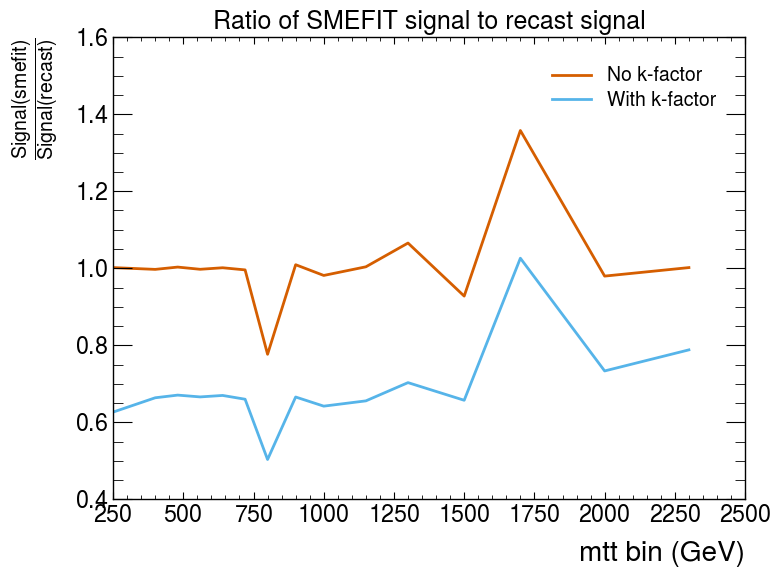

In [9]:
plt.plot(bins_left,signal_smefit/signal_bin,label='No k-factor')
plt.plot(bins_left,signal_smefit/(kfac*signal_bin),label='With k-factor')
plt.xlabel('mtt bin (GeV)')
plt.ylabel(r'$\frac{\rm Signal (smefit)}{\rm Signal (recast)}$')
plt.title('Ratio of SMEFIT signal to recast signal',fontsize=18)
plt.legend()
plt.show()

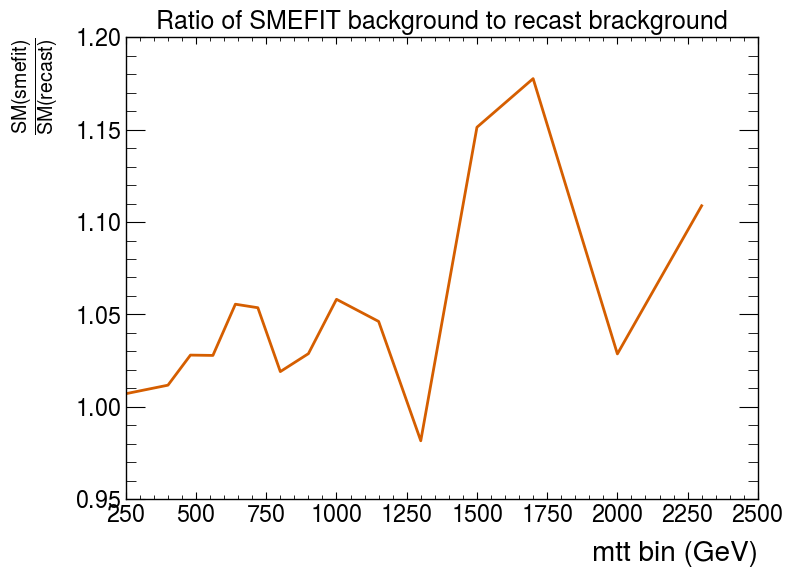

In [10]:

plt.plot(bins_left,sm_NLO_smefit/sm_bin)
plt.xlabel('mtt bin (GeV)')
plt.ylabel(r'$\frac{\rm SM (smefit)}{\rm SM (recast)}$')
plt.title('Ratio of SMEFIT background to recast brackground',fontsize=18)
plt.show()

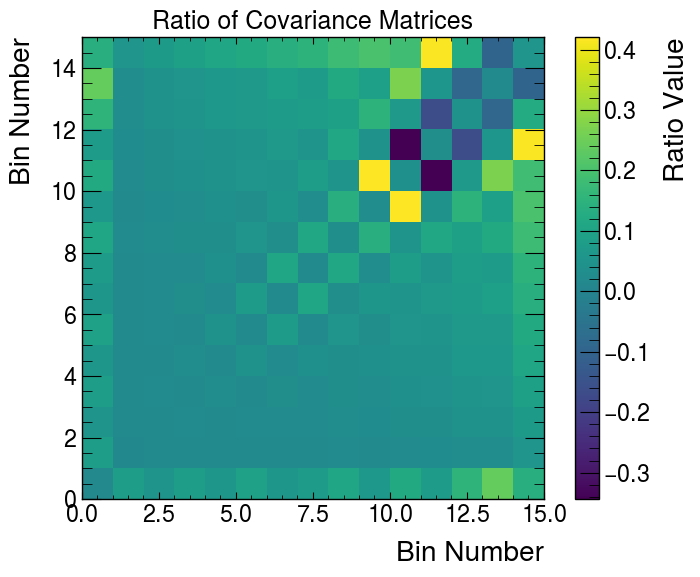

In [11]:
cov_ratio = cov_smefit/covMatrix
plt.figure(figsize=(8, 6))
plt.imshow(cov_ratio, cmap='viridis', origin='lower', extent=[0, cov_ratio.shape[1], 0, cov_ratio.shape[0]])
plt.colorbar(label='Ratio Value')
plt.title('Ratio of Covariance Matrices',fontsize=18)
plt.xlabel('Bin Number')
plt.ylabel('Bin Number')
plt.show()